# MiniPAR Calibration using Multi-Channel Spec
## Calibrate MiniPAR sensor using AS7341 multi-channel spectral data
This notebook reads multi-channel 'spec' output, performs multi-input linear regression against a reference PAR sensor, inspects coefficients, visualizes fit quality, analyzes channel independence, and validates the calibration.

## Setup: Imports and Helper Functions

In [9]:
import sys
import time
import serial
import glob
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Configuration
BAUD_RATE = 115200


## Device Discovery
Automatically detect MiniPAR, reference sensor, and DC source ports, or specify manually.

In [10]:
# Auto-detect ports (or specify manually)
from helpers import findDevice

PORT_MINIPAR = None
PORT_REF = None
PORT_DC = None


In [14]:

# Try auto-detection
print("Scanning for MiniPAR...")
if not PORT_MINIPAR:
    PORT_MINIPAR = findDevice(question="hello\n",answer="MiniPAR",flush=True,timeout=2)
if not PORT_MINIPAR:
    print("MiniPAR not found. Set PORT_MINIPAR manually in next cell.")

print("\nScanning for reference sensor (TIA)...")
if not PORT_REF:
    PORT_REF = findDevice(question="\x01", answer="raw", flush=True, timeout=2)
    if(PORT_REF):
        with serial.Serial(PORT_REF) as ser:
            ser.write("\x02\x04".encode())
            ser.flush()
if not PORT_REF:
    print("Reference sensor not found. Set PORT_REF manually in next cell.")
if not PORT_DC:
    PORT_DC = findDevice(question="*IDN?\nalize ports for DC supply", answer="KIPRIM", flush=True, timeout=2)
if not PORT_DC:
    print("DC supply not found. Set PORT_DC manually in next cell.")

print(f"\nPORT_MINIPAR: {PORT_MINIPAR}")
print(f"PORT_REF: {PORT_REF}")
print(f"PORT_DC: {PORT_DC}")

Scanning for MiniPAR...

Scanning for reference sensor (TIA)...
Received message: MicroPython v1.27.0 on 2025-12-09; Raspberry Pi Pico with RP2040
Type "help()" for more information.
>>> 
raw REPL; CTRL-B to exit
>, port: /dev/ttyACM1
Found device at: /dev/ttyACM1, answer: MicroPython v1.27.0 on 2025-12-09; Raspberry Pi Pico with RP2040
Type "help()" for more information.
>>> 
raw REPL; CTRL-B to exit
>

PORT_MINIPAR: /dev/ttyACM0
PORT_REF: /dev/ttyACM1
PORT_DC: /dev/ttyUSB0


In [15]:
# Uncomment and set if auto-detection fails
# PORT_MINIPAR = "/dev/ttyUSB0"
# PORT_DC = "/
# Verify ports are set
assert PORT_MINIPAR, "PORT_MINIPAR not set"
assert PORT_REF, "PORT_REF not set"
print(f"Using MiniPAR at {PORT_MINIPAR}, Reference at {PORT_REF}")

Using MiniPAR at /dev/ttyACM0, Reference at /dev/ttyACM1


## Serial Communication Functions

In [16]:
def get_spec(port):
    """Request 'spec' from MiniPAR and return list of channel floats."""
    with serial.Serial(port, baudrate=BAUD_RATE, timeout=1) as ser:
        ser.reset_input_buffer()
        ser.write("spec\n".encode())
        time.sleep(0.2)
        line = ser.readline().decode(errors='ignore').strip()
    if not line:
        raise RuntimeError(f"No response from {port}")
    
    parts = [p.strip() for p in line.split(',') if p.strip()]
    # Skip device name if present
    try:
        if parts[0] and not parts[0][0].isdigit():
            parts = parts[1:]
    except Exception:
        pass
    
    return np.array([float(x) for x in parts], dtype=float)

# read mini Par
def get_par(port, raw=False):
    with serial.Serial(port, baudrate=115200) as ser:
        ser.flush()
        if raw:
            ser.write("par_raw\n".encode())
        else:
            ser.write("par\n".encode())
        r = ser.readline()
        #print(r)

        return float(r.decode().strip())
        #print(r)



def getPAR_TIA(port):
    with serial.Serial(port) as ser:
        ser.flush()
        ser.write("getPAR()\r".encode())
        response = ser.readline()# skip echo
        #print(response)
        response = ser.readline()
        #print(response)
    return float(response)



    


def set_current(port, current):
    """Set current on DC source."""
    with serial.Serial(port, baudrate=BAUD_RATE, timeout=1) as ser:
        ser.reset_input_buffer()
        msg = f"current {current:.3f}\r\n".encode()
        ser.write(msg)
        time.sleep(0.1)

print("Serial functions loaded.")

print(getPAR_TIA(PORT_REF))
print(get_spec(PORT_MINIPAR))
print(get_par(PORT_MINIPAR, raw=True))

Serial functions loaded.
0.59064408
[]
0.11


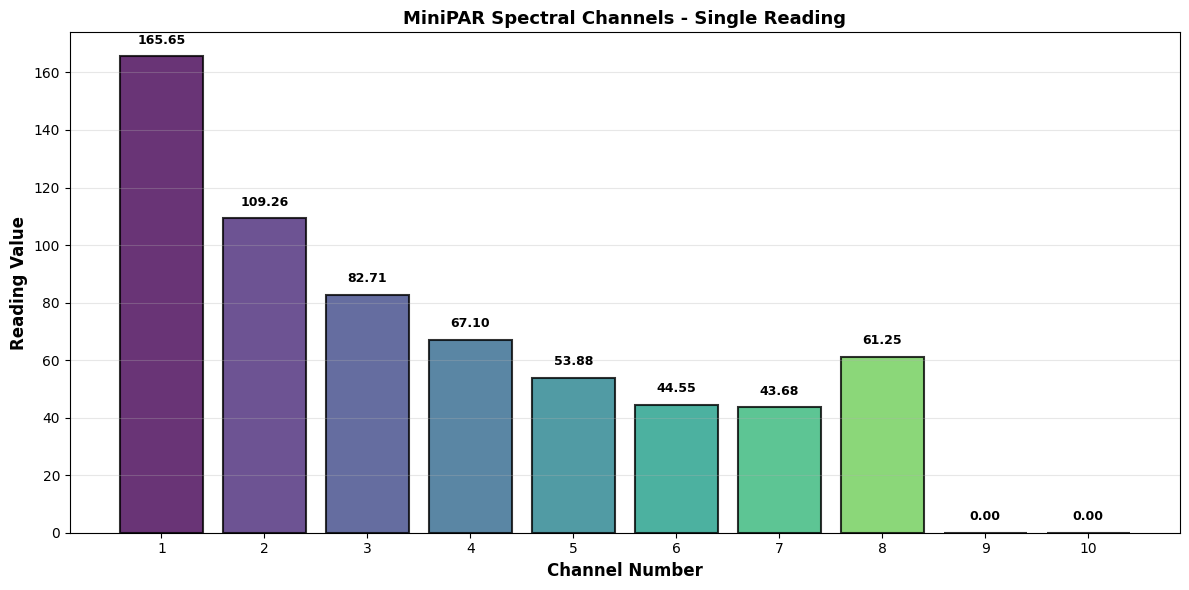


Channel readings: [165.6545 109.2636  82.7056  67.1026  53.8797  44.5536  43.6793  61.2477
   0.       0.    ]
Number of channels: 10


In [ ]:
# test reading
single_reading = get_spec(PORT_MINIPAR)

all_channel_names = ["f1_415", "f2_445", "f3_480", "f4_515",
                     "f5_555", "f6_590", "f7_630", "f8_680",
                     "clear",  "nir"]

# Display channel readings on bar graph
fig, ax = plt.subplots(figsize=(12, 6))
channels = np.arange(1, len(single_reading) + 1)
colors = plt.cm.viridis(np.linspace(0, 1, len(single_reading)))
bars = ax.bar(channels, single_reading, color=colors, edgecolor='black', linewidth=1.5, alpha=0.8)

# Add value labels on top of bars
for i, (bar, value) in enumerate(zip(bars, single_reading)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(single_reading)*0.02, 
            f'{value:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Channel', fontsize=12, fontweight='bold')
ax.set_ylabel('Reading Value', fontsize=12, fontweight='bold')
ax.set_title('MiniPAR Spectral Channels - Single Reading', fontsize=13, fontweight='bold')
ax.set_xticks(channels)
ax.set_xticklabels(all_channel_names, rotation=45, ha='right')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\nChannel readings:")
for name, value in zip(all_channel_names, single_reading):
    print(f"  {name}: {value:.4f}")
print(f"\nNumber of channels: {len(single_reading)}")


In [63]:
# spectral changes with different current levels
test_currents = [1.5, 1.7, 2.0, 2.3, 2.5, 2.8, 3.0, 0]
spectral_data = []
normalized_data = []

print("Collecting spectral data across current levels...\n")
print(f"{'Current (A)':<12} {'Sum':<12} {'Channels':<10}")
print("-" * 40)

for current in test_currents:
    if PORT_DC:
        set_current(PORT_DC, current)
    
    time.sleep(5)  # Wait 5 seconds
    
    try:
        spec = get_spec(PORT_MINIPAR)
        spectral_data.append(spec)
        
        # Normalize so sum equals 1
        spec_normalized = spec / np.sum(spec)
        normalized_data.append(spec_normalized)
        
        print(f"{current:<12.2f} {np.sum(spec):<12.4f} {len(spec):<10}")
    except Exception as e:
        print(f"{current:<12.2f} ERROR: {e}")

normalized_data = np.array(normalized_data)



Current (A)  Sum          Channels  
----------------------------------------
1.50         5.8299       10        
1.70         14.3794      10        
2.00         41.6962      10        
2.30         96.0309      10        
2.50         153.5369     10        
2.80         279.7145     10        
3.00         361.8994     10        
0.00         0.0934       10        


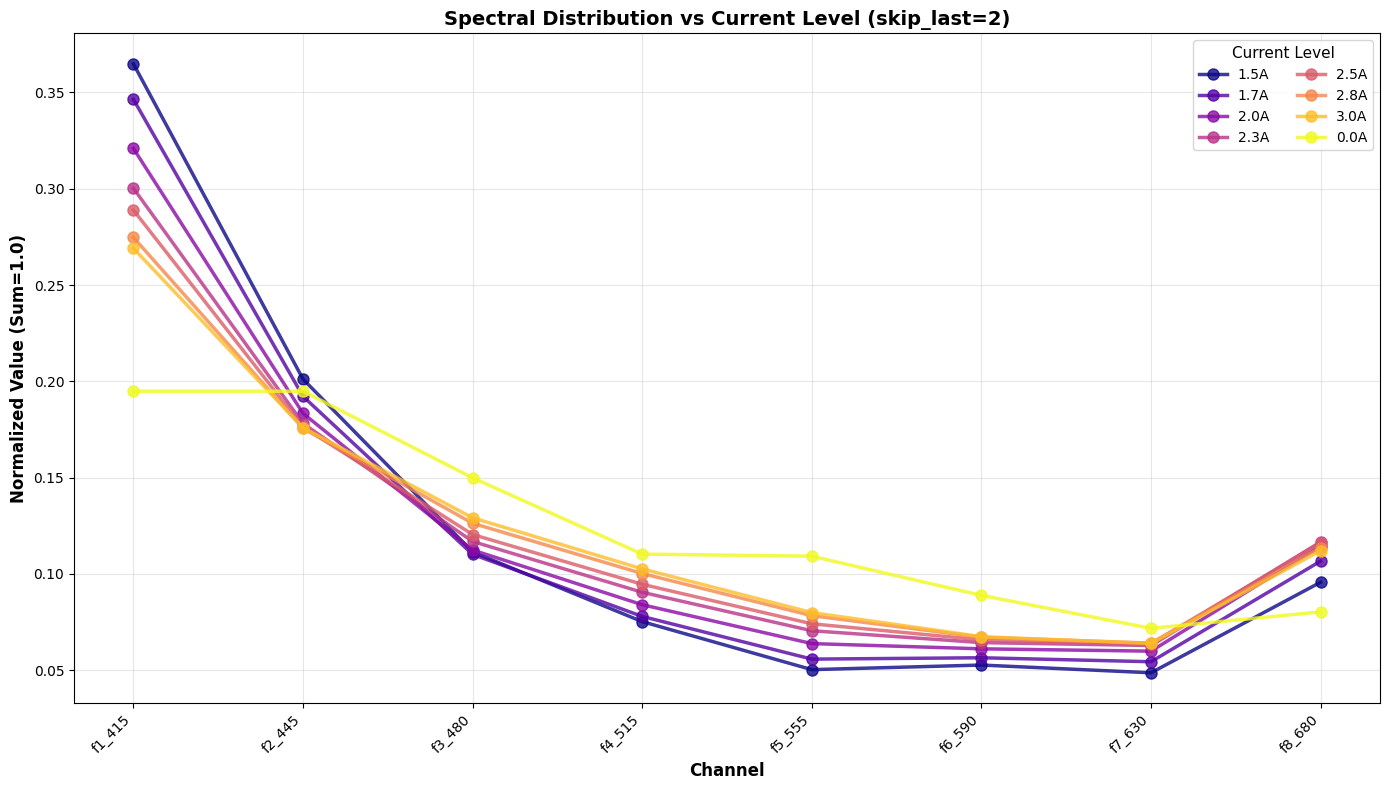


Collected 8 normalized spectra
Displaying 8 channels (skipped 2)
Superimposed plot saved to spectral_changes_normalized.png


In [66]:
# Create superimposed plot showing spectral changes with current level
fig, ax = plt.subplots(figsize=(14, 8))

# Channel names
all_channel_names = ["f1_415", "f2_445", "f3_480", "f4_515",
                     "f5_555", "f6_590", "f7_630", "f8_680",
                     "clear",  "nir"]

# Skip last N channels (e.g., set to 2 to exclude "clear" and "nir")
skip_last_channels = 2
channel_names = all_channel_names[:-skip_last_channels] if skip_last_channels > 0 else all_channel_names

# Use a colormap to distinguish different current levels
colors = plt.cm.plasma(np.linspace(0, 1, len(test_currents)))

for idx, (current, normalized_spec) in enumerate(zip(test_currents, normalized_data)):
    # Select only the channels we want to plot
    if skip_last_channels > 0:
        selected_spec = normalized_spec[:-skip_last_channels]
    else:
        selected_spec = normalized_spec
    
    channels = np.arange(1, len(selected_spec) + 1)
    ax.plot(channels, selected_spec, marker='o', linewidth=2.5, markersize=8, 
            label=f'{current:.1f}A', color=colors[idx], alpha=0.8)

ax.set_xlabel('Channel', fontsize=12, fontweight='bold')
ax.set_ylabel('Normalized Value (Sum=1.0)', fontsize=12, fontweight='bold')
ax.set_title(f'Spectral Distribution vs Current Level (skip_last={skip_last_channels})', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(title='Current Level', fontsize=10, title_fontsize=11, loc='best', ncol=2)
ax.set_xticks(np.arange(1, len(channel_names) + 1))
ax.set_xticklabels(channel_names, rotation=45, ha='right')

plt.tight_layout()
plt.savefig('spectral_changes_normalized.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"\nCollected {len(normalized_data)} normalized spectra")
print(f"Displaying {len(channel_names)} channels (skipped {skip_last_channels})")
print("Superimposed plot saved to spectral_changes_normalized.png")


## Data Collection
Collect spectral data and reference PAR values across multiple current levels.

In [44]:
# Configure current levels for calibration sweep
DEFAULT_CURRENTS = [0.8, 1.2, 1.8, 1.9, 2.2, 2.3, 2.4, 2.6, 3.0, 0.0]
currents = DEFAULT_CURRENTS
print(f"Calibration currents: {currents}")

X_list = []  # Spectral channels
y_list = []  # Reference PAR values

print("\nStarting data collection...\n")
for I in currents:
    if PORT_DC:
        set_current(PORT_DC, I)
    time.sleep(1.0)
    
    try:
        ref = getPAR_TIA(PORT_REF)
        spec = get_spec(PORT_MINIPAR)
        X_list.append(spec)
        y_list.append(ref)
        print(f"I={I:.2f}A  ref_PAR={ref:8.4f}  spec[0]={spec[0]:8.4f}  (channels: {len(spec)})")
    except Exception as e:
        print(f"I={I:.2f}A  ERROR: {e}")
        continue

X = np.vstack(X_list)
y = np.array(y_list)

print(f"\nCollected {len(y)} samples with {X.shape[1]} channels")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Calibration currents: [0.8, 1.2, 1.8, 1.9, 2.2, 2.3, 2.4, 2.6, 3.0, 0.0]

Starting data collection...

I=0.80A  ref_PAR=  0.5660  spec[0]=  0.0182  (channels: 10)
I=1.20A  ref_PAR=  0.5660  spec[0]=  0.0182  (channels: 10)
I=1.80A  ref_PAR=  2.6883  spec[0]=  0.5818  (channels: 10)
I=1.90A  ref_PAR=  8.3889  spec[0]=  1.0364  (channels: 10)
I=2.20A  ref_PAR= 23.6398  spec[0]=  2.2364  (channels: 10)
I=2.30A  ref_PAR= 31.9563  spec[0]=  2.8000  (channels: 10)
I=2.40A  ref_PAR= 41.5314  spec[0]=  3.4727  (channels: 10)
I=2.60A  ref_PAR= 68.2082  spec[0]=  5.0364  (channels: 10)
I=3.00A  ref_PAR=138.6638  spec[0]=  8.6545  (channels: 10)
I=0.00A  ref_PAR=  0.6153  spec[0]=  0.0182  (channels: 10)

Collected 10 samples with 10 channels
X shape: (10, 10)
y shape: (10,)


## Linear Regression: Multiple Input Channels

In [45]:
def compute_coeffs(X, y):
    """Fit multi-input linear regression: y ≈ X @ c + intercept"""
    # Add intercept column
    A = np.hstack([X, np.ones((X.shape[0], 1))])  # [ch1, ch2, ..., 1]
    coeffs, residuals, rank, s = np.linalg.lstsq(A, y, rcond=None)
    return coeffs, residuals, rank, s


def r_squared(y_true, y_pred):
    """Calculate R² fit quality."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return 1.0 if ss_res == 0 else 0.0
    return 1 - ss_res / ss_tot


# Perform regression
coeffs, residuals, rank, s = compute_coeffs(X, y)
intercept = coeffs[-1]
channels_coeffs = coeffs[:-1]

y_pred = (X @ channels_coeffs) + intercept
r2 = r_squared(y, y_pred)
rmse = np.sqrt(np.mean((y - y_pred) ** 2))

print("=" * 60)
print("LINEAR REGRESSION RESULTS")
print("=" * 60)
print(f"\nMatrix rank: {rank} / {X.shape[1]}")
print(f"Residual norm: {np.linalg.norm(residuals):.6g}")
print(f"\nFit Quality:")
print(f"  R²: {r2:.8g}")
print(f"  RMSE: {rmse:.8g}")
print(f"\nCoefficients:")
for i, c in enumerate(channels_coeffs, start=1):
    print(f"  Channel {i}: {c:.8g}")
print(f"  Intercept:  {intercept:.8g}")
print("=" * 60)

LINEAR REGRESSION RESULTS

Matrix rank: 9 / 10
Residual norm: 0

Fit Quality:
  R²: 1
  RMSE: 8.606846e-14

Coefficients:
  Channel 1: -46.680881
  Channel 2: 86.156282
  Channel 3: -156.49247
  Channel 4: 369.01764
  Channel 5: -339.25178
  Channel 6: 133.52277
  Channel 7: 70.508543
  Channel 8: -1.5830472
  Channel 9: 0
  Channel 10: 0
  Intercept:  -0.18161641


## Analysis: Channel Independence (SVD)

In [46]:
# Perform SVD on normalized spectral data
X_normalized = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-10)
U, singular_values, Vt = np.linalg.svd(X_normalized, full_matrices=False)

# Compute condition number and variance explained
cond_number = singular_values[0] / singular_values[-1] if singular_values[-1] > 0 else np.inf
variance_explained = (singular_values ** 2) / np.sum(singular_values ** 2)
cumulative_variance = np.cumsum(variance_explained)

print("\n" + "=" * 60)
print("CHANNEL INDEPENDENCE ANALYSIS (SVD)")
print("=" * 60)
print(f"\nCondition number: {cond_number:.4g}")
print(f"  (>100 suggests channel redundancy/collinearity)")
print(f"\nSingular values: {singular_values}")
print(f"\nVariance explained by each component:")
for i, (var, cumvar) in enumerate(zip(variance_explained, cumulative_variance), start=1):
    print(f"  PC{i}: {var*100:6.2f}% (cumulative: {cumvar*100:6.2f}%)")

# Find number of components needed for 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"\nComponents for 95% variance: {n_components_95} / {len(singular_values)}")
if n_components_95 < len(singular_values):
    print(f"  ⚠ Suggests {len(singular_values) - n_components_95} channels are redundant")

print("=" * 60)


CHANNEL INDEPENDENCE ANALYSIS (SVD)

Condition number: inf
  (>100 suggests channel redundancy/collinearity)

Singular values: [8.94024975e+00 2.64671085e-01 3.97141702e-02 1.43793299e-02
 8.61940892e-03 4.78489328e-03 1.40096676e-03 6.49540250e-04
 0.00000000e+00 0.00000000e+00]

Variance explained by each component:
  PC1:  99.91% (cumulative:  99.91%)
  PC2:   0.09% (cumulative: 100.00%)
  PC3:   0.00% (cumulative: 100.00%)
  PC4:   0.00% (cumulative: 100.00%)
  PC5:   0.00% (cumulative: 100.00%)
  PC6:   0.00% (cumulative: 100.00%)
  PC7:   0.00% (cumulative: 100.00%)
  PC8:   0.00% (cumulative: 100.00%)
  PC9:   0.00% (cumulative: 100.00%)
  PC10:   0.00% (cumulative: 100.00%)

Components for 95% variance: 1 / 10
  ⚠ Suggests 9 channels are redundant


## Visualization: Fit Quality and Channel Analysis

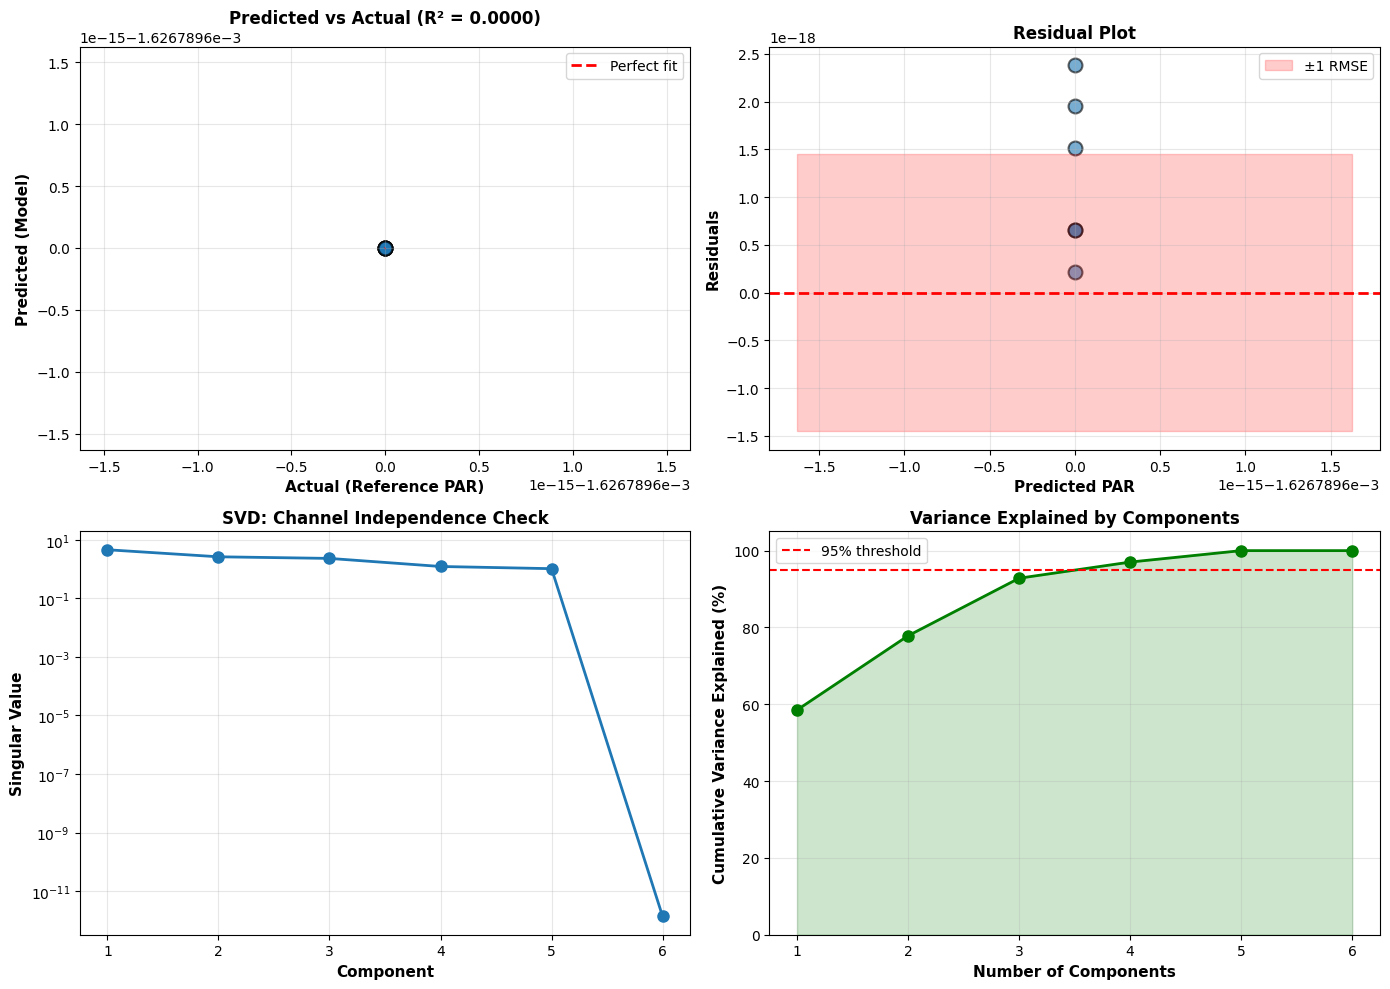

Plots saved to calibration_fit_analysis.png


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Predicted vs Actual
ax = axes[0, 0]
ax.scatter(y, y_pred, s=100, alpha=0.6, edgecolors='k', linewidth=1.5)
lims = [np.min([y.min(), y_pred.min()]), np.max([y.max(), y_pred.max()])]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect fit')
ax.set_xlabel('Actual (Reference PAR)', fontsize=11, fontweight='bold')
ax.set_ylabel('Predicted (Model)', fontsize=11, fontweight='bold')
ax.set_title(f'Predicted vs Actual (R² = {r2:.4f})', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 2: Residuals
ax = axes[0, 1]
residuals_data = y - y_pred
ax.scatter(y_pred, residuals_data, s=100, alpha=0.6, edgecolors='k', linewidth=1.5)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.fill_between(ax.get_xlim(), -rmse, rmse, alpha=0.2, color='red', label=f'±1 RMSE')
ax.set_xlabel('Predicted PAR', fontsize=11, fontweight='bold')
ax.set_ylabel('Residuals', fontsize=11, fontweight='bold')
ax.set_title('Residual Plot', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Plot 3: Singular Values (log scale)
ax = axes[1, 0]
ax.semilogy(np.arange(1, len(singular_values)+1), singular_values, 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Component', fontsize=11, fontweight='bold')
ax.set_ylabel('Singular Value', fontsize=11, fontweight='bold')
ax.set_title('SVD: Channel Independence Check', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, which='both')

# Plot 4: Cumulative Variance Explained
ax = axes[1, 1]
ax.plot(np.arange(1, len(cumulative_variance)+1), cumulative_variance*100, 'o-', linewidth=2, markersize=8, color='green')
ax.axhline(y=95, color='r', linestyle='--', lw=1.5, label='95% threshold')
ax.fill_between(np.arange(1, len(cumulative_variance)+1), 0, cumulative_variance*100, alpha=0.2, color='green')
ax.set_xlabel('Number of Components', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative Variance Explained (%)', fontsize=11, fontweight='bold')
ax.set_title('Variance Explained by Components', fontsize=12, fontweight='bold')
ax.set_ylim([0, 105])
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('calibration_fit_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

print("Plots saved to calibration_fit_analysis.png")

## Coefficient Inspection & Approval
**Review the coefficients below before uploading.** Adjust if needed.

In [28]:
# Display coefficients for inspection
print("\n" + "=" * 60)
print("CALIBRATION COEFFICIENTS FOR UPLOAD")
print("=" * 60)
coeffs_display = coeffs.copy()
print(f"\nCommand format: cal_par_coeffs,<c1>,<c2>,...,<intercept>")
print(f"\nFull coefficient array (including intercept):")
print(coeffs_display)

# CSV format for upload
coeffs_csv = ",".join([f"{c:.6g}" for c in coeffs_display])
print(f"\nCSV format for upload:")
print(coeffs_csv)

# Save to JSON for later use
coeffs_data = {
    'coeffs': coeffs_display.tolist(),
    'channel_coeffs': channels_coeffs.tolist(),
    'intercept': float(intercept),
    'r2': float(r2),
    'rmse': float(rmse),
    'condition_number': float(cond_number),
    'timestamp': None  # Will be filled if uploaded
}

with open('calibration_coeffs.json', 'w') as f:
    json.dump(coeffs_data, f, indent=2)
print(f"\nCoefficients saved to calibration_coeffs.json")
print("=" * 60)


CALIBRATION COEFFICIENTS FOR UPLOAD

Command format: cal_par_coeffs,<c1>,<c2>,...,<intercept>

Full coefficient array (including intercept):
[-5.57173126e-04 -8.63567030e-17  7.22271434e-06  1.32897944e-05
 -9.65292299e-16 -2.76870717e-05  2.53207286e-15 -1.71835207e-04
  0.00000000e+00  0.00000000e+00 -2.47138224e-04]

CSV format for upload:
-0.000557173,-8.63567e-17,7.22271e-06,1.32898e-05,-9.65292e-16,-2.76871e-05,2.53207e-15,-0.000171835,0,0,-0.000247138

Coefficients saved to calibration_coeffs.json


## Upload Coefficients
**Run this cell only after reviewing the coefficients above.**

In [ ]:
# CONFIRM UPLOAD
CONFIRM_UPLOAD = False  # Set to True to enable upload

def upload_coeffs(port, coeffs):
    """Upload coefficients to MiniPAR."""
    vals = ",".join([f"{c:.6g}" for c in coeffs])
    cmd = f"cal_par_coeffs,{vals}\n"
    print(f"Sending: {cmd.strip()}")
    
    with serial.Serial(port, baudrate=BAUD_RATE, timeout=1) as ser:
        ser.reset_input_buffer()
        ser.write(cmd.encode())
        time.sleep(0.2)
        resp = ser.readline().decode(errors='ignore').strip()
    return resp

if CONFIRM_UPLOAD:
    print(f"Uploading coefficients to {PORT_MINIPAR}...")
    try:
        response = upload_coeffs(PORT_MINIPAR, coeffs)
        print(f"Upload response: {response}")
        print("✓ Coefficients uploaded successfully!")
    except Exception as e:
        print(f"✗ Upload failed: {e}")
else:
    print("Upload disabled. Set CONFIRM_UPLOAD = True to proceed.")

## Post-Validation: Verify Calibration
Compare MiniPAR 'par' readings against reference sensor at several current levels.

In [ ]:
# Wait for user to run post-validation
print("\nPost-validation requires running the calibrated device.")
print("Ensure coefficients have been uploaded and device rebooted if needed.\n")

# Test currents (subset of calibration range)
test_currents = [0.3, 0.7, 1.2]
validation_data = []

print("Running validation sweep...\n")
print(f"{'Current (A)':<15} {'Reference (PAR)':<20} {'MiniPAR (PAR)':<20} {'Error (abs)':<15} {'Error (%)':<15}")
print("-" * 85)

for I in test_currents:
    if PORT_DC:
        set_current(PORT_DC, I)
    time.sleep(1.0)
    
    try:
        ref = getPAR_TIA(PORT_REF)
        par = get_par(PORT_MINIPAR)
        error_abs = abs(par - ref)
        error_pct = (error_abs / ref * 100) if ref != 0 else 0
        
        validation_data.append({
            'current': I,
            'ref': ref,
            'par': par,
            'error_abs': error_abs,
            'error_pct': error_pct
        })
        
        print(f"{I:<15.2f} {ref:<20.4f} {par:<20.4f} {error_abs:<15.4f} {error_pct:<15.2f}%")
    except Exception as e:
        print(f"{I:<15.2f} ERROR: {e}")

if validation_data:
    errors_abs = [d['error_abs'] for d in validation_data]
    errors_pct = [d['error_pct'] for d in validation_data]
    print("-" * 85)
    print(f"{'Mean error':<15} {np.mean([d['ref'] for d in validation_data]):<20.4f} {np.mean([d['par'] for d in validation_data]):<20.4f} {np.mean(errors_abs):<15.4f} {np.mean(errors_pct):<15.2f}%")
    print("\nValidation complete.")
else:
    print("No validation data collected.")

## Validation Summary

In [ ]:
if validation_data:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    # Plot 1: Reference vs Calibrated PAR
    ax = axes[0]
    refs = [d['ref'] for d in validation_data]
    pars = [d['par'] for d in validation_data]
    ax.scatter(refs, pars, s=150, alpha=0.7, edgecolors='k', linewidth=2)
    lims = [min(refs + pars), max(refs + pars)]
    ax.plot(lims, lims, 'r--', lw=2, label='Perfect agreement')
    ax.set_xlabel('Reference Sensor PAR', fontsize=11, fontweight='bold')
    ax.set_ylabel('MiniPAR (Calibrated) PAR', fontsize=11, fontweight='bold')
    ax.set_title('Post-Validation: MiniPAR vs Reference', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Plot 2: Validation Errors
    ax = axes[1]
    currents_val = [d['current'] for d in validation_data]
    errors_pct = [d['error_pct'] for d in validation_data]
    colors = ['green' if e < 5 else 'orange' if e < 10 else 'red' for e in errors_pct]
    ax.bar(range(len(currents_val)), errors_pct, color=colors, alpha=0.7, edgecolor='k', linewidth=1.5)
    ax.axhline(y=5, color='green', linestyle='--', lw=1.5, label='5% threshold')
    ax.axhline(y=10, color='orange', linestyle='--', lw=1.5, label='10% threshold')
    ax.set_xticks(range(len(currents_val)))
    ax.set_xticklabels([f"{c:.1f}A" for c in currents_val])
    ax.set_ylabel('Absolute Error (%)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Test Current', fontsize=11, fontweight='bold')
    ax.set_title('Validation Errors by Current Level', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('validation_results.png', dpi=100, bbox_inches='tight')
    plt.show()
    
    print("Validation plot saved to validation_results.png")
else:
    print("No validation data to plot.")